# Comparator Atlas: When Calibration Is Not Enough

**Wei-Lun Hsu — National Tsing Hua University**

**IEEE SSCS Code-a-Chip — ISSCC 2027**  
License: MIT · Tools: SKY130, ngspice, Magic, Netgen and Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sscs-ose/sscs-ose-code-a-chip.github.io/blob/main/ISSCC27/submitted_notebooks/comparator_atlas/Comparator_Atlas.ipynb)

[Run the submitted version in Colab](https://colab.research.google.com/github/WLHsu0827/sscs-ose-code-a-chip.github.io/blob/wlhsu0827-comparator-atlas-isscc27/ISSCC27/submitted_notebooks/comparator_atlas/Comparator_Atlas.ipynb)
before the official main-branch badge is available.

## Abstract

Offset calibration alone does not ensure that a regenerative comparator
makes a correct decision before its deadline. Comparator Atlas explores
this tradeoff using a SKY130 StrongARM comparator with physical trim
devices. The notebook compares nine sizing/threshold candidates,
evaluates calibration policies across PVT conditions, and follows the
selected design into actual layout and parasitic extraction. Interactive
waveforms connect circuit behavior to decision time and core energy.
Schematic and extracted results are compared under explicitly stated
conditions. A 45-condition nominal extracted-RC study reaches the
declared 2 ns deadline at all 180 sampled inputs, with a measured
worst-case decision time of 1.835 ns.

## Getting started

Run all cells to verify the supplied data and regenerate the analysis.
Set `RUN_LIVE_SPICE` for a small fresh simulation or
`RUN_FULL_CAMPAIGN` for the complete schematic study.
Tool versions, full commands and evidence locations are in
[Reproducibility](REPRODUCIBILITY.md).

In [1]:
from pathlib import Path
import importlib.util
from importlib import metadata
import subprocess
import sys

parts = (
    "ISSCC27", "submitted_notebooks", "comparator_atlas"
)
source = Path.cwd() / "comparator-atlas-source"
candidates = [
    Path.cwd(),
    Path.cwd().joinpath(*parts),
    source.joinpath(*parts),
]
entry_root = next(
    (p for p in candidates if (p / "entry_tools.py").is_file()),
    None,
)
if entry_root is None:
    if source.exists():
        raise RuntimeError(
            "An incomplete source directory already exists. "
            "Inspect it before retrying; it was not overwritten."
        )
    repository = (
        "https://github.com/WLHsu0827/"
        "sscs-ose-code-a-chip.github.io.git"
    )
    branch = "wlhsu0827-comparator-atlas-isscc27"
    subprocess.run(
        [
            "git", "clone", "--quiet", "--depth", "1",
            "--filter=blob:none", "--no-checkout",
            "--single-branch", "--branch", branch,
            repository, str(source),
        ],
        check=True,
    )
    subprocess.run(
        [
            "git", "-C", str(source), "sparse-checkout",
            "set", str(Path(*parts)),
        ],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(source), "checkout", "--quiet", branch],
        check=True,
    )
    entry_root = source.joinpath(*parts)
    if not (entry_root / "entry_tools.py").is_file():
        raise RuntimeError("The downloaded entry is incomplete.")
required = {
    "numpy": "2.2.6",
    "pandas": "2.2.3",
    "matplotlib": "3.10.3",
    "nbformat": "5.10.4",
    "ipywidgets": "8.1.7",
}
needs_setup = []
for name, version in required.items():
    if importlib.util.find_spec(name) is None:
        needs_setup.append(name)
    elif metadata.version(name) != version:
        needs_setup.append(name)
if needs_setup:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "-r", str(entry_root / "requirements-review.txt"),
        ],
        check=True,
    )
stale = []
for name, version in required.items():
    loaded = sys.modules.get(name)
    if loaded is not None:
        loaded_version = getattr(loaded, "__version__", version)
        if loaded_version != version:
            stale.append(name)
if stale:
    raise RuntimeError(
        "Dependencies were updated but older packages are loaded. "
        "Restart the kernel/runtime once, then Run all."
    )
sys.path.insert(0, str(entry_root))
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
import entry_tools as entry
import layout_evidence as physical

%matplotlib inline
release_checksums = entry_root / "entry_checksums.json"
if release_checksums.is_file():
    import json
    support_hashes = json.loads(
        release_checksums.read_text(encoding="utf-8")
    )
    support_hashes.pop("Comparator_Atlas.ipynb", None)
    entry.verify_files(
        entry_root,
        support_hashes,
    )
    print(
        "Public support files verified. The notebook itself "
        "remains editable for execution-mode switches."
    )
else:
    print(
        "Development checkout: sealed experiment manifests "
        "will be verified; no release file map is present."
    )
RUN_LIVE_SPICE = False
RUN_FULL_CAMPAIGN = False
print("Python:", sys.version.split()[0])
print("Default: verified supplied evidence, not a fresh SPICE run.")

Development checkout: sealed experiment manifests will be verified; no release file map is present.
Python: 3.10.18
Default: verified supplied evidence, not a fresh SPICE run.


## 1. Decision-time and energy measurements

At deadline $T$ after the evaluation clock midpoint, the decision is
valid only if **both** complementary outputs reach their assigned
rails: one at least $0.8V_{\mathrm{DD}}$, the other at most
$0.2V_{\mathrm{DD}}$. Its sign must equal that of the externally
applied differential input. A resolved opposite sign is **wrong**;
a missing complementary-rail decision is **unresolved**.
Zero input is not counted in pass fractions.

The sampled decision time excludes an early output glitch: it is the
first saved valid sample after the final invalid sample, through the
reporting deadline. A 1 ns decision deadline does not mean that a
1 GHz clock was tested; the clock period is 10 ns.

$$E_{\mathrm{core}}=-V_{\mathrm{DD}}
\int_{20\,\mathrm{ns}}^{30\,\mathrm{ns}} I_{V_{\mathrm{DD}}}(t)\,dt.$$

The full third cycle includes reset. Two previous cycles provide
warmup. Input common mode is half the supply, clock edges are 50 ps,
and each output carries a 5 fF ideal load unless an explicitly named
interface stress changes that condition.

Runs are checked for reset and complete waveform data. Pass fractions
describe the listed test grid, not manufacturing yield.

## 2. Offset calibration

A zero-input trim scan locates candidates near a sign change. Input
bisection then brackets confirmed opposite decisions. The score is

$$M_T=\max(|v_-(T)|,\ |v_+(T)|).$$

A wide unresolved interval is retained rather than replaced by its
midpoint. The host search minimizes the larger absolute endpoint,
with 0.2 mV input-bracket resolution and a local monotonicity assumption.

The long-deadline policy uses 3.5 ns; a separate ablation applies the
same procedure at 1 ns. A TT/1.8 V/27 C reference-code policy transfers
a single code across model corners. It is **not** a per-die factory
calibration at an unknown fixed process corner.

## 3. Comparator circuit and design selection

During reset, four PFETs precharge the internal and output nodes.
When the clock rises, the tail conducts and the input pair starts
discharging the internal nodes. Cross-coupled feedback regenerates
the differential signal into complementary outputs. Device imbalance
shifts the switching boundary; the auxiliary branches provide trim.

The conventional StrongARM core has eleven transistor instances,
including four reset PFETs. Each trim magnitude bit adds one auxiliary
analog input NFET and its digital source-gating NFET on each side.
The selected circuit has 27 instances and **four magnitude bits plus
sign**, supporting codes -15 through +15. An on-chip decoder and
calibration controller are not implemented.

The auxiliary analog gates track their respective input. No ideal
source simply subtracts a fitted offset. All trim devices remain
physically present at code zero; comparison within a design therefore
retains its trim parasitic loading.

Nine candidates vary device threshold flavor, dimensions and trim
range. LVT applies to the main and auxiliary analog input paths;
latch, tail and digital switches remain standard-VT.

Selection used three PVT conditions and six inputs, with 2x mean
training core-energy and 4x gate-area-proxy budgets. The ranking
maximizes worst-case training coverage, then mean coverage, followed
by boundary magnitude, energy and gate geometry. The gate-area proxy
is the sum of transistor W times L, not placed/routed area.
The first prototype informed the family. All rejected candidates
remain visible in the recorded selection.

The schematic uses enhancement-mode MOS symbols and explicitly
connected regenerative feedback. A reset symbol represents one
device for each listed node; the trim pair repeats for bits 0–3
on both sides. Identical node labels in different panels connect
electrically. Body ties are stated beneath the drawing.
[Vector schematic](results/presentation/circuit_guide.pdf).

,design,input_device,transistors,gate_area_um2,worst_training_coverage,mean_training_core_fj,eligible
0,baseline,nfet_01v8,23,10.83,0.000000,141.994479,True
1,svt_fast_4b,nfet_01v8,27,22.20,0.000000,267.328362,True
2,lvt_base_3b,nfet_01v8_lvt,23,10.83,0.833333,160.380620,True
3,lvt_fine_3b,nfet_01v8_lvt,23,16.71,0.666667,196.648509,True
4,lvt_balanced_4b,nfet_01v8_lvt,27,20.55,0.833333,257.144356,True
5,lvt_fine_4b,nfet_01v8_lvt,27,33.15,0.833333,330.052380,False
6,lvt_fast_4b,nfet_01v8_lvt,27,22.20,0.833333,295.022182,False
7,lvt_fast_fine_4b,nfet_01v8_lvt,27,34.80,0.833333,367.560860,False
8,lvt_wide_5b,nfet_01v8_lvt,31,41.64,0.666667,496.946536,False


Frozen selected design: lvt_balanced_4b


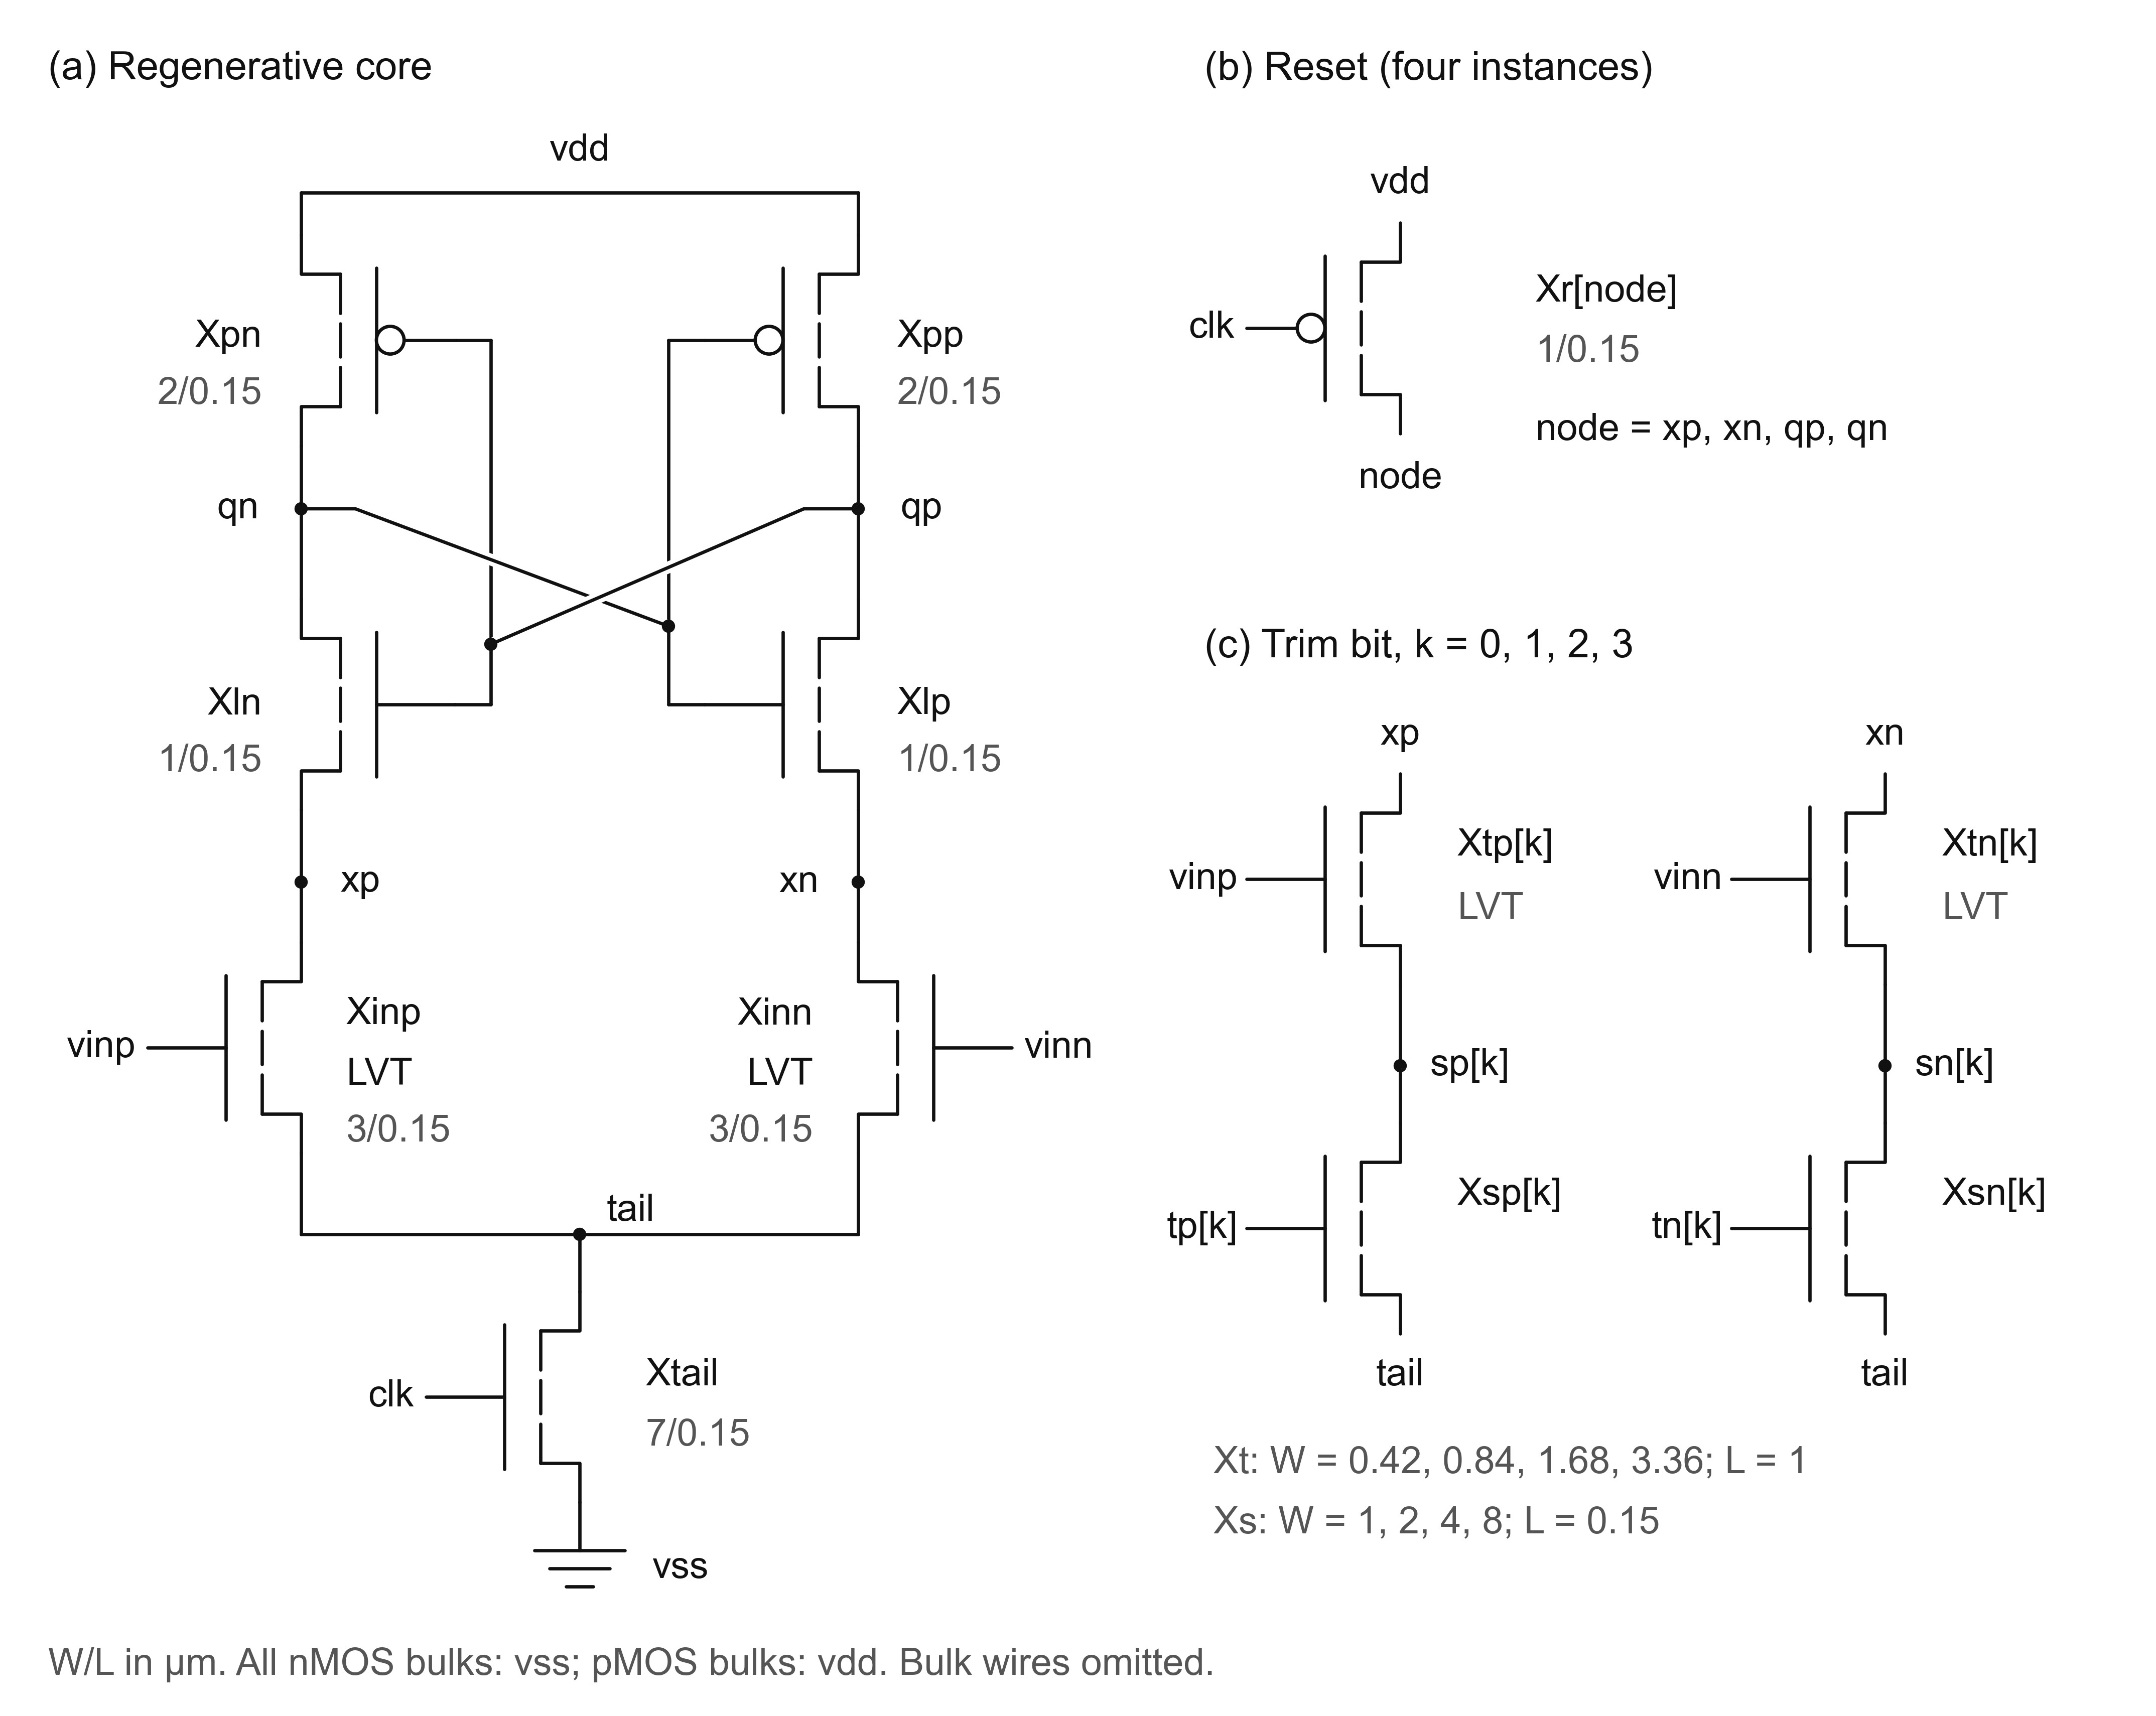

In [2]:
if RUN_FULL_CAMPAIGN:
    entry.full_reproduction()
evidence = entry.load_evidence()
selection = evidence["selection"]
candidates = pd.DataFrame([
    {
        "design": item["design"]["name"],
        "input_device": item["design"]["input_device"],
        "transistors": item["design"]["transistor_count"],
        "gate_area_um2": item["design"]["gate_area_proxy_um2"],
        "worst_training_coverage":
            item["worst_case_correct_fraction"],
        "mean_training_core_fj": item["mean_core_energy_fj"],
        "eligible": item["eligible"],
    }
    for item in selection["candidates"]
])
display(candidates)
print("Frozen selected design:", selection["selected_design"])
display(Image(filename=str(physical.circuit_guide_path())))

## 4. Schematic results across PVT

The complete [selected SPICE netlist](results/study/selected_circuit.spice)
is provided with the source.

The original comparison has 45 PVT combinations at one controlled
main-pair width skew, plus four additional nominal skew controls:
49 conditions per circuit. This is not every mismatch value at every
PVT combination. With +4% skew, the two branch widths use multipliers
1.04 and 0.96. This deliberately controlled perturbation is **not a
foundry Monte Carlo mismatch distribution**.

The selected/original comparison uses validation inputs distinct from
the six current selection inputs. The three selection conditions
remain identifiable; they are not relabeled as independent data.

**Post-selection control.** An existing lower-energy LVT candidate,
`lvt_base_3b`, is characterized on the same 49 conditions with code
zero and local calibration. This addresses a stronger engineering
question than comparison with the original circuit alone: whether
the selected circuit's extra energy is justified by the desired
decision band. This control was declared after viewing the original
comparison and does not constitute a new blinded test set.

The next tables show both average and worst-condition coverage.
A design with a favorable average is not automatically acceptable
if even one required condition fails.

Local policy; 1 ns; sampled |input| >= 1 mV


,correct,points,grid_coverage,fully_passing_conditions,conditions,worst_condition_coverage,mean_core_energy_fj,simulated_points,gate_area_proxy_um2
design,,,,,,,,,
baseline,310,392,0.790816,16,49,0.000,143.013776,392,10.83
lvt_balanced_4b,372,392,0.948980,29,49,0.875,251.525212,392,20.55
lvt_base_3b,351,392,0.895408,18,49,0.250,156.646856,392,10.83


Same policy and deadline; sampled |input| >= 3 mV


,correct,points,grid_coverage,fully_passing_conditions,conditions,worst_condition_coverage,mean_core_energy_fj,simulated_points,gate_area_proxy_um2
design,,,,,,,,,
baseline,253,294,0.860544,40,49,0.000000,141.285960,294,10.83
lvt_balanced_4b,294,294,1.000000,49,49,1.000000,249.655122,294,20.55
lvt_base_3b,285,294,0.969388,43,49,0.333333,154.972252,294,10.83


,design,minimum_abs_input_mv,deadline_ns,correct,points,all_sampled_conditions_pass,worst_condition_coverage
0,baseline,0.25,1.0,406,588,False,0.000000
1,lvt_balanced_4b,0.25,1.0,502,588,False,0.750000
2,lvt_base_3b,0.25,1.0,460,588,False,0.166667
3,baseline,0.50,1.0,360,490,False,0.000000
4,lvt_balanced_4b,0.50,1.0,440,490,False,0.800000
5,lvt_base_3b,0.50,1.0,407,490,False,0.200000
6,baseline,1.00,1.0,310,392,False,0.000000
7,lvt_balanced_4b,1.00,1.0,372,392,False,0.875000
8,lvt_base_3b,1.00,1.0,351,392,False,0.250000
9,baseline,3.00,1.0,253,294,False,0.000000


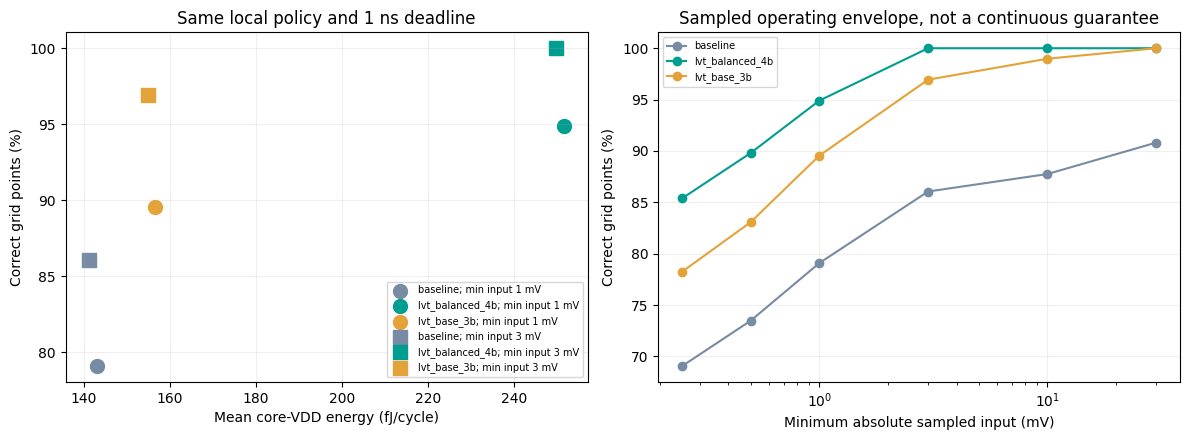

In [3]:
print("Local policy; 1 ns; sampled |input| >= 1 mV")
display(entry.summary(evidence, minimum_mv=1.0))
print("Same policy and deadline; sampled |input| >= 3 mV")
display(entry.summary(evidence, minimum_mv=3.0))
display(entry.sampled_envelope(evidence))
figure = entry.tradeoff_figure(evidence)
display(figure)
plt.close(figure)

In [4]:
import ipywidgets as widgets


def inspect_tradeoff(minimum_mv, deadline_ns):
    display(entry.summary(evidence, minimum_mv, deadline_ns))


minimum_control = widgets.SelectionSlider(
    options=[0.25, 0.5, 1.0, 3.0, 10.0, 30.0],
    value=1.0,
    description="Min |input| (mV)",
    continuous_update=False,
    style={"description_width": "initial"},
)
deadline_control = widgets.SelectionSlider(
    options=[0.25, 0.35, 0.5, 0.75, 1.0, 2.0],
    value=1.0,
    description="Deadline (ns)",
    continuous_update=False,
    style={"description_width": "initial"},
)
interactive_table = widgets.interactive_output(
    inspect_tradeoff,
    {
        "minimum_mv": minimum_control,
        "deadline_ns": deadline_control,
    },
)
display(minimum_control, deadline_control, interactive_table)

SelectionSlider(continuous_update=False, description='Min |input| (mV)', index=2, options=(0.25, 0.5, 1.0, 3.0…

SelectionSlider(continuous_update=False, description='Deadline (ns)', index=4, options=(0.25, 0.35, 0.5, 0.75,…

Output()

## 5. Time-step consistency

The original 10-to-5 ps refinement exposed fourteen failed deadline
checks across seven physical points. Refinement to 0.625 ps produced
two consecutive passing halving comparisons under the unchanged
limits: identical decision/outcome, at most 1% core-energy difference
and at most 20 ps resolved-latency difference.

The finest accepted waveform replaces **every** matching policy and
deadline observation, including corrections that make the circuit
look worse. Original coarse tables and the full refinement history
remain available. No circuit, code, stimulus, deadline or frozen
candidate choice changes during this process.

The added energy-efficient control checks every nonzero input point
under both policies at 10 and 5 ps, then applies the same stricter
halving rule to sensitive points. Unresolved sensitivity blocks its
inclusion as a completed comparison.

These are numerical checks for declared observations, not proof of
stability at every continuous input, random-noise immunity or
production signoff.

In [5]:
numerical = pd.DataFrame([
    {
        "study": "original / selected",
        "initial_failed_checks":
            evidence["stress"]["initial_numerical_failures"],
        "final_failed_checks":
            evidence["stress"]["numerical_failures"],
        "refined_physical_points":
            evidence["stress"]["refined_physical_points"],
    },
    {
        "study": "post-selection lower-energy control",
        "initial_failed_checks":
            evidence["control"]["initial_failed_checks"],
        "final_failed_checks":
            evidence["control"]["final_failed_checks"],
        "refined_physical_points":
            evidence["control"]["refined_physical_points"],
    },
])
display(numerical)

,study,initial_failed_checks,final_failed_checks,refined_physical_points
0,original / selected,14,0,7
1,post-selection lower-energy control,7,0,2


## 6. Waveforms and decision behavior

The following small, hash-checked waveform set is distributed with the
entry. It is not a synthetic behavioral model. The same measurement
function used in the campaign recomputes reset validity, rail-valid
decisions, latency and full-cycle core energy.

The weak SS/low-voltage/cold condition was known during selection.
These traces illustrate mechanism; the complete condition tables
support the finite-grid comparison.

,design,input_mv,deadline_ns,outcome,decision_time_ns,core_energy_fj
0,baseline,-3.0,1.0,unresolved,NaN,78.313915
1,baseline,3.0,1.0,unresolved,NaN,78.462953
2,lvt_base_3b,-3.0,1.0,unresolved,NaN,108.661417
3,lvt_base_3b,3.0,1.0,correct,0.904695,104.904111
4,lvt_balanced_4b,-3.0,1.0,correct,0.585887,167.225006
5,lvt_balanced_4b,3.0,1.0,correct,0.840738,169.951086


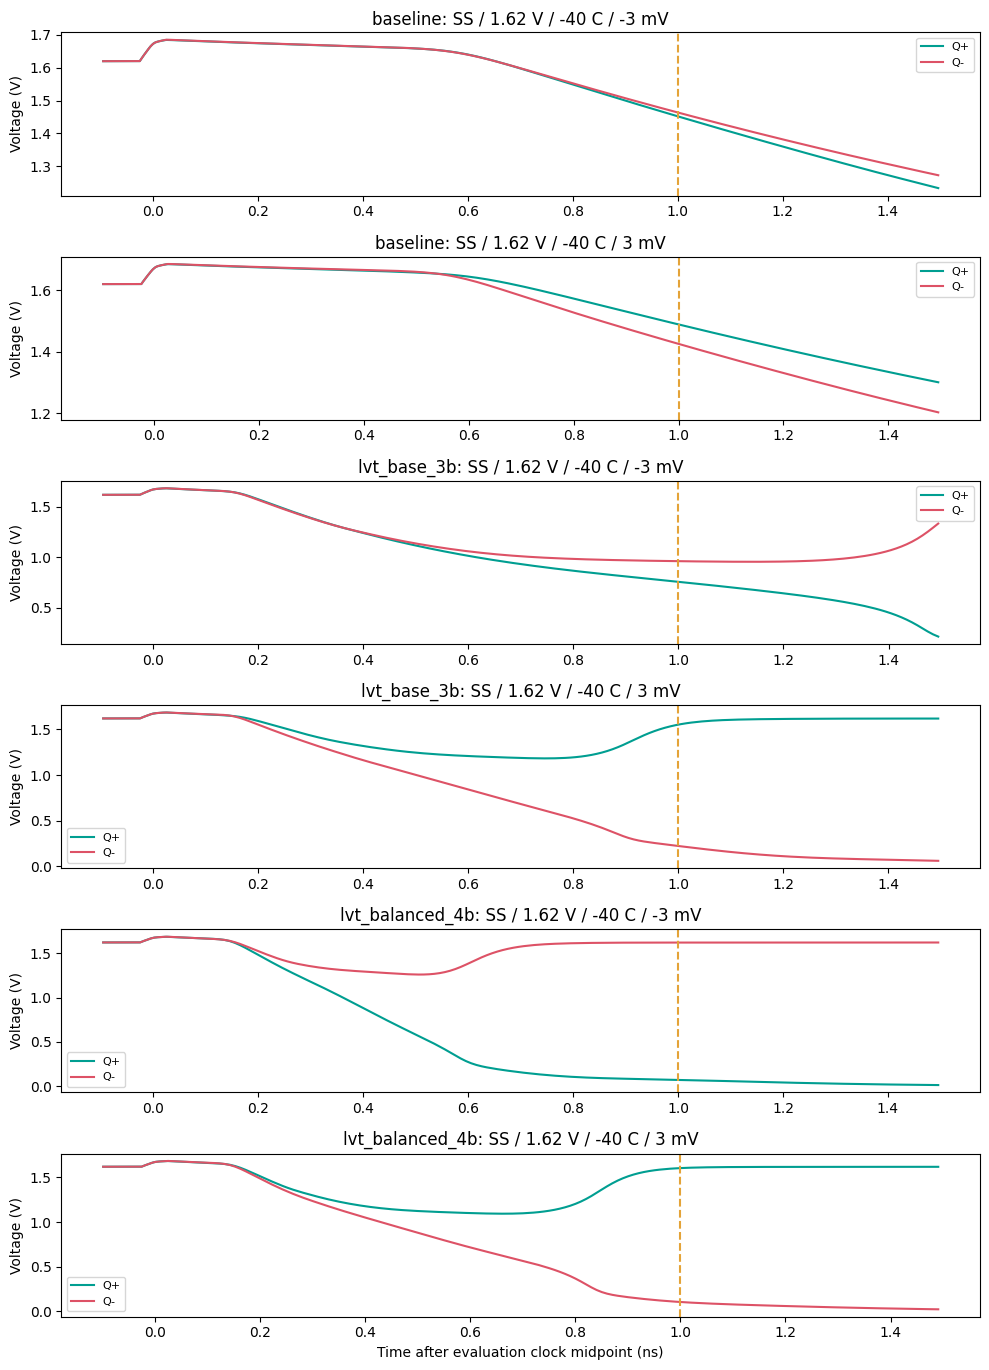

Waveform metrics recomputed from checked saved SPICE data. Set RUN_LIVE_SPICE=True for fresh transistor simulation.


In [6]:
measured, figure = entry.review_waveforms()
display(measured[[
    "design", "input_mv", "deadline_ns", "outcome",
    "decision_time_ns", "core_energy_fj",
]])
display(figure)
plt.close(figure)
if RUN_LIVE_SPICE:
    display(entry.live_spice_smoke())
else:
    print(
        "Waveform metrics recomputed from checked saved SPICE data. "
        "Set RUN_LIVE_SPICE=True for fresh transistor simulation."
    )

### Waveform lab: wrong, late, or correct?

These controls show eight representative saved SPICE waveforms.
Compare the complementary output rails with the selected deadline.

Start with the **code-zero -1 mV schematic example**: its outputs
resolve to the wrong polarity. Switch to the same circuit and
input with calibration enabled, then to a cold-SS extracted RC
example. At 1 ns that RC trace is late; reading its saved 2 ns
observation does not retroactively pass the original 1 ns gate.

Horizontal dotted lines are the fixed 80% / 20% output rail
thresholds. The two cursor voltages, not only their difference,
determine whether the decision is valid. Core energy always
covers the complete saved 10 ns cycle.

In [7]:
from presentation import waveform_lab

lab = waveform_lab.load_lab()


def inspect_waveform(example, deadline_ns):
    figure, reading = waveform_lab.figure(
        lab, example, deadline_ns
    )
    display(figure, pd.DataFrame([{
        key: reading[key] for key in (
            "outcome", "deadline_ns", "Q+_at_deadline_V",
            "Q-_at_deadline_V", "sampled_decision_time_ns",
            "full_cycle_core_energy_fJ",
        )
    }]))
    plt.close(figure)


example_control = widgets.Dropdown(
    options=[
        (sample["label"], sample["id"])
        for sample in lab["samples"]
    ],
    value="schematic_untrimmed",
    description="Stored waveform",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="95%"),
)
waveform_deadline = widgets.SelectionSlider(
    options=lab["deadlines_ns"],
    value=1.0,
    description="Deadline (ns)",
    continuous_update=False,
    style={"description_width": "initial"},
)
waveform_output = widgets.interactive_output(
    inspect_waveform,
    {
        "example": example_control,
        "deadline_ns": waveform_deadline,
    },
)
display(example_control, waveform_deadline, waveform_output)

Dropdown(description='Stored waveform', layout=Layout(width='95%'), options=(('Wrong is not late: code zero', …

SelectionSlider(continuous_update=False, description='Deadline (ns)', index=4, options=(0.25, 0.35, 0.5, 0.75,…

Output()

## 7. Input-interface sensitivity and calibration cost

Five original/selected PVT conditions are stressed with input history,
finite source resistance and capacitance, altered common mode, and
increased output loading. The calibration code is frozen before the
interface changes. Results include the unfavorable cases: the faster
LVT path can inject larger deterministic input disturbances and does
not necessarily improve a heavily loaded interface.

The measured pin error includes settling and kickback, not random
thermal noise. These interface results apply to the original and
selected circuits; the added lower-energy control has not silently
inherited them.

Calibration workload below counts distinct simulated probes. Each
probe simulates three 10 ns cycles. This is **offline experiment
workload**, not an implemented calibration latency or total on-chip
energy. A practical system also needs reference/input generation,
switching, a controller and storage; those implementation costs
remain outside the measured core-rail energy.

In [8]:
display(entry.operating_summary(evidence))
display(entry.calibration_workload(evidence))

points  correct  \
design_name     stress                                    
baseline        ideal_reference             20       10   
                opposite_input_history      20       10   
                source_1k_20f               20        6   
                source_5k_20f               20        6   
                settling_10k_200f           20        6   
                common_mode_0p45            20       10   
                common_mode_0p60            20       10   
                output_load_20f             20        7   
lvt_balanced_4b ideal_reference             20       19   
                opposite_input_history      20       19   
                source_1k_20f               20       11   
                source_5k_20f               20       10   
                settling_10k_200f           20        8   
                common_mode_0p45            20       10   
                common_mode_0p60            20       13   
                output_load_20f             20        6   

                                        peak_differential_input_error_mv  
design_name     stress                                                    
baseline        ideal_reference                             2.602085e-15  
                opposite_input_history                      2.602085e-15  
                source_1k_20f                               5.345645e+01  
                source_5k_20f                               9.792325e+01  
                settling_10k_200f                           3.273007e+01  
                common_mode_0p45                            2.602085e-15  
                common_mode_0p60                            1.118897e-13  
                output_load_20f                             2.602085e-15  
lvt_balanced_4b ideal_reference                             2.602085e-15  
                opposite_input_history                      2.602085e-15  
                source_1k_20f                               1.320953e+02  
                source_5k_20f                               1.814124e+02  
                settling_10k_200f                           5.905097e+01  
                common_mode_0p45                            2.602085e-15  
                common_mode_0p60                            1.118897e-13  
                output_load_20f                             2.602085e-15

,minimum_distinct_probes,maximum_distinct_probes,median_distinct_probes,maximum_offline_simulated_duration_ns
design,,,,
baseline,37,139,48.0,4170
lvt_balanced_4b,53,64,64.0,1920
lvt_base_3b,37,48,48.0,1440


## 8. Layout and post-layout results

The layout uses the same selected 27-device circuit with nominally
matched main inputs and code zero. It does not reproduce the
schematic width-skew experiment as intentional geometry.
Fifteen ordered ports, exact device flavors/dimensions/body ties,
and actual mask geometry are checked before simulation.

A first legal layout had positive-input failures after extraction.
Balanced routing repaired the capacitive environment; a compact
routing revision then required four real M2 bridges to eliminate
narrow PFET body-pad notches. This final physical repair passes
named-style DRC, independent LVS and deliberately wrong connection,
bulk, width and SVT/LVT negative controls. It is not foundry signoff.

**Three separate electrical exports:** connectivity-only LVS,
C-only extraction, and distributed RC extraction. All native
elements and their annotations remain retained. The GDS view below
is parsed from the actual hash-checked file, not a drawn floorplan.

,layout,bbox_area_um2,m2_union_area_um2,rc_resistors,rc_capacitors,listed_rc_capacitance_ff,drc_errors,lvs_and_negative_controls
0,initial_legal_comb,4281.984,520.4124,672,319,266.51579,0,pass
1,balanced_legal_r1,3297.024,433.1344,675,321,256.75391,0,pass
2,repaired_compact,2207.088,80.3847,675,319,181.43686,0,pass


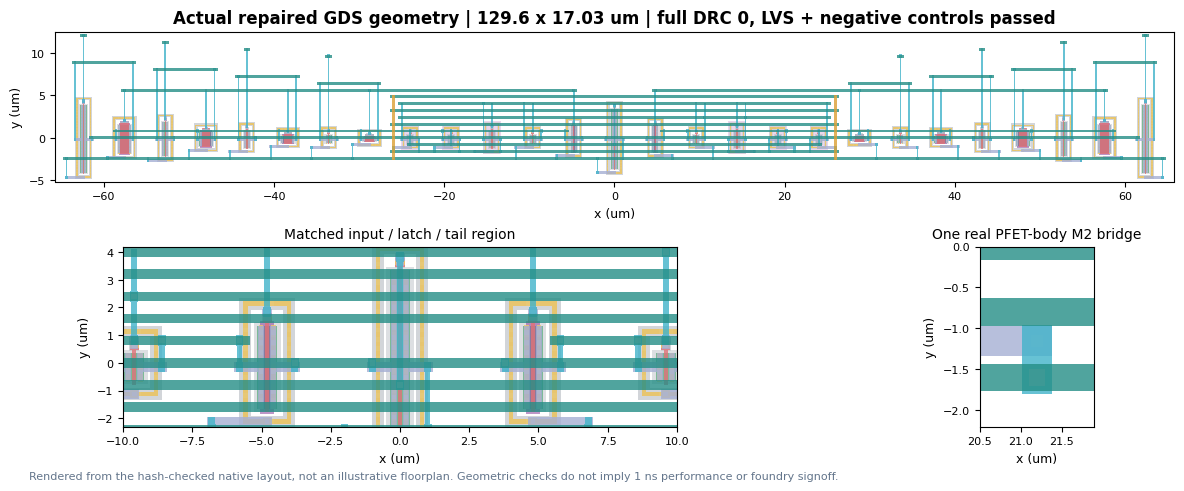

,implementation,mean_delay_ns,mean_core_energy_fj,matched_signed_points
0,Schematic,0.280439,244.052099,2
1,Repaired Connectivity only,0.279745,244.059216,2
2,Repaired C-only,0.499627,355.926931,2
3,Previous balanced RC,0.842877,520.839216,2
4,Repaired Distributed RC,0.645110,425.358034,2


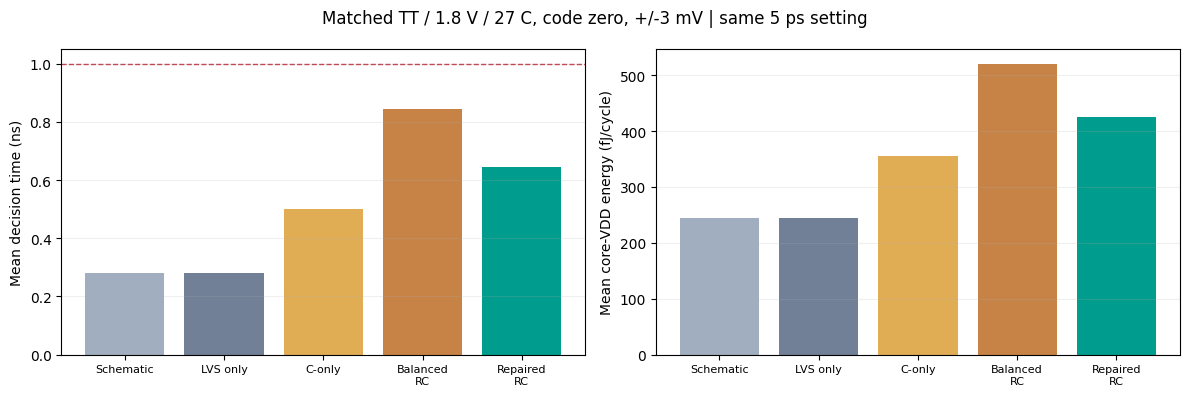

In [9]:
layout = physical.load_layout()
display(physical.geometry_summary(layout))
figure = physical.layout_figure(layout)
display(figure)
plt.close(figure)
display(physical.matched_tt_comparison(layout))
figure = physical.tt_cost_figure(layout)
display(figure)
plt.close(figure)

### Earlier five-condition layout comparison

At matched TT +/-3 mV points, compact RC routing reduces mean
delay from 0.843 to 0.645 ns and core energy from 521 to 425 fJ
relative to the prior legal balanced layout. The matched schematic
uses 244 fJ. This compares complete layouts, not the isolated effect
of the pad repair.

RC meets the original 1 ns deadline at 12/20 sampled points;
eight SS points are late. The same retained traces give 20/20
correct points at 2 ns. That is a post-hoc observation, not a
revised 1 ns pass. This earlier ngspice-42 study covers five
conditions and four inputs (+/-3, +/-10 mV) per mode. Its results
remain separate from the following ngspice-47 full-grid study.

,mode,deadline_ns,sampled_points,correct,wrong,unresolved,scope
0,Schematic,1,20,20,0,0,original pilot
1,Schematic,2,20,20,0,0,post-hoc retained-window characterization
2,Connectivity only,1,20,20,0,0,original pilot
3,Connectivity only,2,20,20,0,0,post-hoc retained-window characterization
4,C-only,1,20,16,0,4,original pilot
5,C-only,2,20,20,0,0,post-hoc retained-window characterization
6,Distributed RC,1,20,12,0,8,original pilot
7,Distributed RC,2,20,20,0,0,post-hoc retained-window characterization


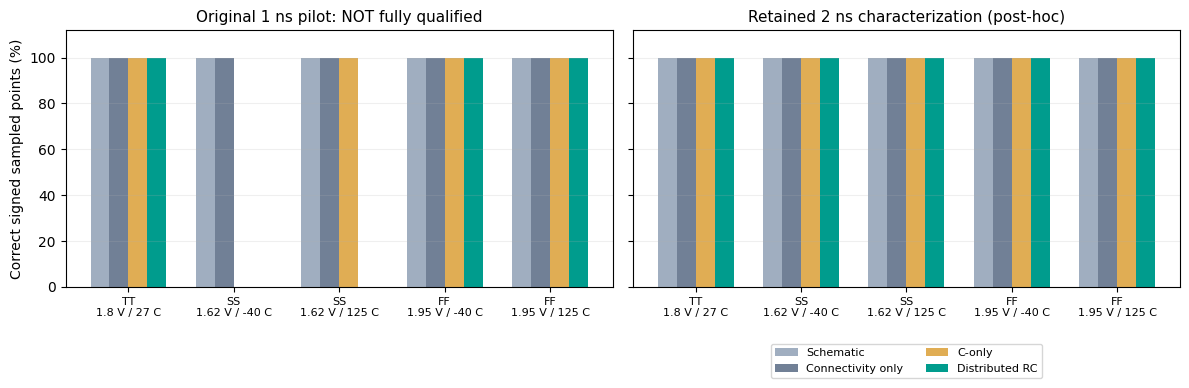

,corner,vdd_v,temperature_c,input_mv,deadline_ns,outcome,decision_time_ns,core_energy_fj
0,tt,1.80,27,-3.0,1,correct,0.656880,426.102768
1,tt,1.80,27,-3.0,2,correct,0.656880,426.102768
2,tt,1.80,27,3.0,1,correct,0.633340,424.613300
3,tt,1.80,27,3.0,2,correct,0.633340,424.613300
4,ss,1.62,-40,-3.0,1,unresolved,NaN,295.568032
5,ss,1.62,-40,-3.0,2,correct,1.581239,295.568032
6,ss,1.62,-40,3.0,1,unresolved,NaN,295.039991
7,ss,1.62,-40,3.0,2,correct,1.561240,295.039991
8,ss,1.62,125,-3.0,1,unresolved,NaN,351.664006
9,ss,1.62,125,-3.0,2,correct,1.229269,351.664006


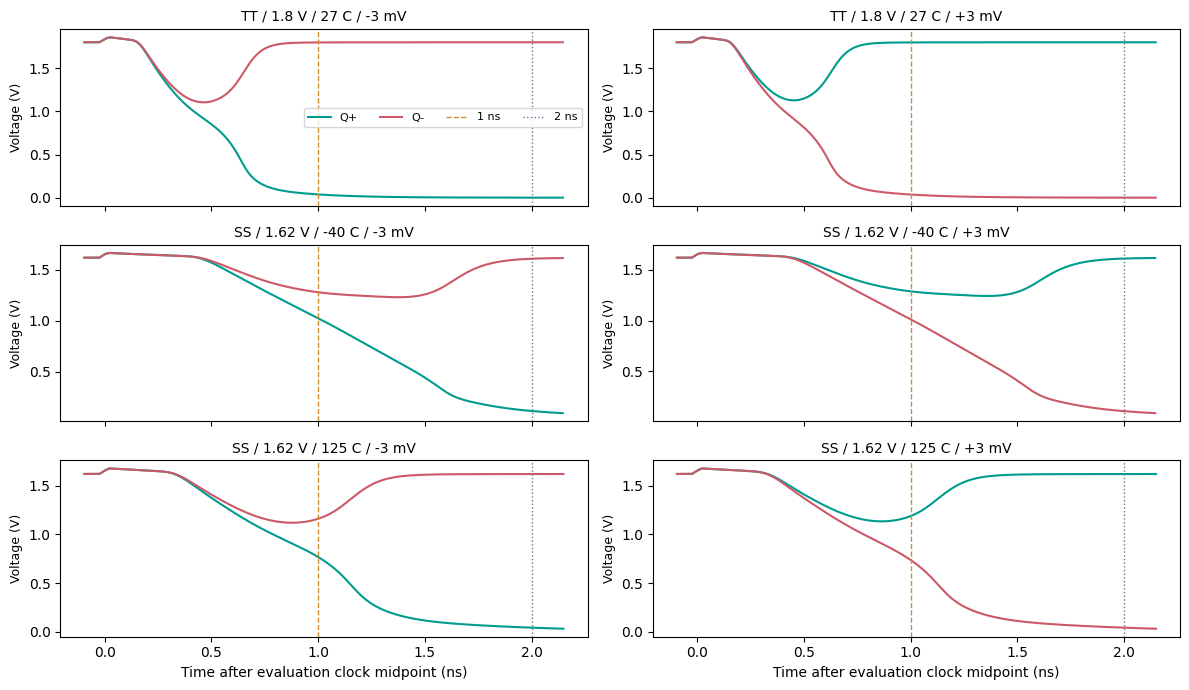

In [10]:
display(physical.deadline_summary(layout))
figure = physical.deadline_figure(layout)
display(figure)
plt.close(figure)
layout_measurements, figure = (
    physical.review_layout_waveforms(layout)
)
display(layout_measurements[[
    "corner", "vdd_v", "temperature_c", "input_mv",
    "deadline_ns", "outcome", "decision_time_ns", "core_energy_fj",
]])
display(figure)
plt.close(figure)

### Full-grid post-layout verification

The same nominal 27-device layout is now evaluated over all five
process corners, three supplies (1.62, 1.80, 1.95 V), and three
temperatures (-40, 27, 125 C). Each of the 45 conditions uses
differential inputs -10, -3, +3 and +10 mV: **180 points per mode**.
Schematic and extracted RC use code zero, common mode 0.5 VDD,
5 fF output loads, and the same 10 ns clock with 50 ps edges.

This new study declares **2 ns** as its primary deadline while also
reporting 1 ns. Both modes were freshly simulated with ngspice 47
at 10 and 5 ps; all 360 pointwise numerical comparisons meet the
fixed decision, 1% energy and 20 ps latency criteria. The five
earlier layout conditions are identified as previously observed;
the other forty are new post-layout conditions, not a blinded test.

**RC is correct at 180/180 sampled points at 2 ns, and 156/180 at
1 ns.** The 24 remaining 1 ns points are unresolved, not wrong-sign
decisions. The slowest sample is FS / 1.62 V / -40 C / -3 mV at
1.835 ns, rather than the SS corner seen in the earlier pilot.
These finite-grid results do not establish statistical yield or
behavior between the listed input values.

,implementation,points,correct_at_1ns,correct_at_2ns,mean_core_energy_fj,mean_delay_ns_at_2ns,worst_delay_ns_at_2ns
0,Schematic,180,180,180,245.835161,0.303294,0.738007
1,Extracted RC,180,156,180,425.490054,0.707601,1.835032


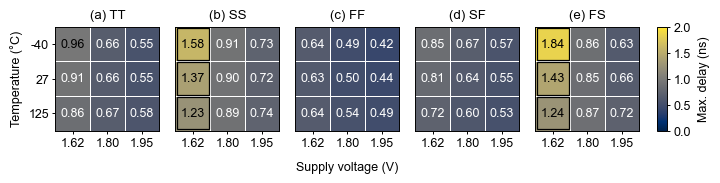

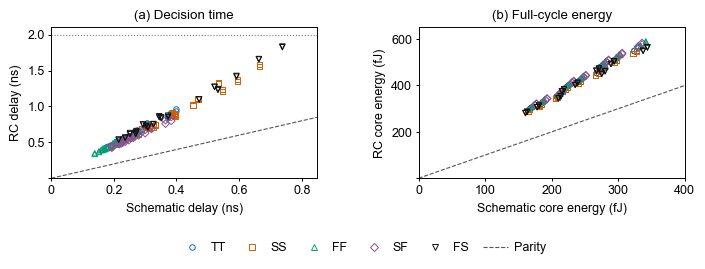

In [11]:
from presentation import pvt45_results as pvt

full_pvt = pvt.load_results()
display(pvt.comparison_table(full_pvt["frame"]))
figure = pvt.timing_figure(full_pvt["frame"])
display(figure)
plt.close(figure)
figure = pvt.tradeoff_figure(full_pvt["frame"])
display(figure)
plt.close(figure)

The PVT map shows the **maximum over the four signed input samples**
in each cell. Black outlines identify conditions containing a missed
1 ns decision; every point meets the primary 2 ns deadline.
The paired plots retain all 180 schematic/RC comparisons, with
marker shape as well as color identifying the process corner.

Mean full-grid core energy is **245.84 fJ schematic versus
425.49 fJ extracted RC**. The mean of the per-point energy overheads
is 73.45%; the ratio of population means is 73.08%. These are
different aggregations and are not interchanged.

[Vector PVT map](results/study/postlayout_pvt45/figures/pvt45_timing.pdf)
· [Vector paired comparison](results/study/postlayout_pvt45/figures/pvt45_comparison.pdf)

The next plot remeasures the original saved schematic/RC pair at
the worst sampled condition. Ten representative traces are provided
for review; they are a subset of the 720 simulations behind the
complete result.

,condition,mode,input_mv,deadline_ns,outcome,decision_time_ns,core_energy_fj
0,TT / 1.8 V / 27 C,schematic,-3.0,1,correct,0.275702,244.050432
1,TT / 1.8 V / 27 C,schematic,-3.0,2,correct,0.275702,244.050432
2,TT / 1.8 V / 27 C,rc,-3.0,1,correct,0.657526,426.104141
3,TT / 1.8 V / 27 C,rc,-3.0,2,correct,0.657526,426.104141
4,TT / 1.8 V / 27 C,schematic,3.0,1,correct,0.275702,244.050432
5,TT / 1.8 V / 27 C,schematic,3.0,2,correct,0.275702,244.050432
6,TT / 1.8 V / 27 C,rc,3.0,1,correct,0.632601,424.615894
7,TT / 1.8 V / 27 C,rc,3.0,2,correct,0.632601,424.615894
8,FF / 1.95 V / 125 C,schematic,-3.0,1,correct,0.205539,341.389949
9,FF / 1.95 V / 125 C,schematic,-3.0,2,correct,0.205539,341.389949


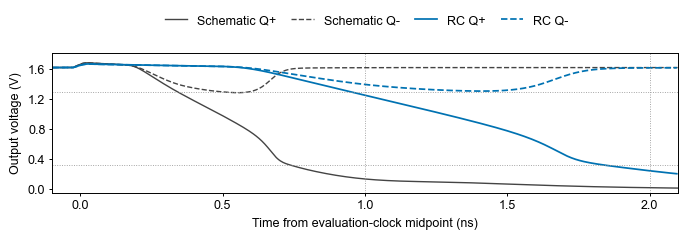

In [12]:
pvt_examples = pvt.review_examples(full_pvt)
display(pvt_examples[[
    "condition", "mode", "input_mv", "deadline_ns",
    "outcome", "decision_time_ns", "core_energy_fj",
]])
figure = pvt.worst_case_figure(full_pvt)
display(figure)
plt.close(figure)

## 9. Discussion and limitations

Calibration improves the switching boundary, while device choice
and loading affect whether regeneration finishes in time. The
lower-energy control and extracted-layout comparison show why
accuracy, delay and energy should be evaluated together.

- Results are deterministic SKY130 simulations. Width perturbations
  are controlled stress, not a foundry mismatch distribution or yield.
- The 49-condition calibrated schematic study, earlier five-condition
  layout experiment and full 45-condition nominal code-zero study
  have separate conditions and recorded tool identities.
- Core-rail energy excludes input/clock drivers and calibration
  infrastructure. DRC/LVS do not establish silicon performance or
  complete foundry signoff.

See [Reproducibility](REPRODUCIBILITY.md) for tool versions, commands,
numerical criteria and the locations of layouts, waveforms and logs.

### References

1. B. Razavi, “The StrongARM Latch [A Circuit for All Seasons],”
   *IEEE Solid-State Circuits Magazine*, vol. 7, no. 2, pp. 12–17,
   2015. DOI: [10.1109/MSSC.2015.2418155](https://doi.org/10.1109/MSSC.2015.2418155).
2. S. Li, Z. Xu and T. Iizuka, “Analysis of strong-arm comparator with
   auxiliary pair for offset calibration,” *Analog Integrated Circuits
   and Signal Processing*, vol. 110, pp. 535–546, 2022.
   DOI: [10.1007/s10470-022-01992-6](https://doi.org/10.1007/s10470-022-01992-6).
3. [Official SKY130 primitive models](https://github.com/google/skywater-pdk-libs-sky130_fd_pr),
   revision `f62031a1be9aefe902d6d54cddd6f59b57627436`.
   Original Apache-2.0 notices are retained.
4. [Open SKY130/GF180 comparator optimization research](https://github.com/ChrisZonghaoLi/sky130_comparator_rl)
   and [an existing SKY130/LVT comparator example](https://github.com/edonD/sky130-comparator).
   Related ideas are credited; their code, figures, performance
   claims and statistical assumptions are not this study's evidence.
5. [ngspice](https://ngspice.sourceforge.io/) and
   [Code-a-Chip rules](https://github.com/sscs-ose/sscs-ose-code-a-chip.github.io).
6. [Magic extraction documentation](https://opencircuitdesign.com/magic/commandref/ext2spice.html),
   [distributed resistance extraction](https://opencircuitdesign.com/magic/commandref/extresist.html),
   and [open_pdks](https://github.com/RTimothyEdwards/open_pdks).

**Acknowledgment.** GitHub Copilot assisted implementation, experiment
automation, figures and documentation. The author is responsible for
the work. Original code is MIT licensed; third-party models and tools
retain their licenses.